[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sensioai/blog/blob/master/032_optimization/optimization.ipynb)

# Optimización

En este post vamos a ver algunas técnicas que podemos aplicar durante el entrenamiento de nuestras `redes neuronales` para acelerar el proceso de optimización y, potencialmente, obtener mejores resultados de los que hemos sido capaces de obtener hasta ahora. Compararemos estas técnicas en el mismo problema utilizado en el post anterior, la clasificación de imágenes con el dataset CIFAR10.

In [1]:
import torchvision

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

len(trainset), len(testset)

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


(50000, 10000)

In [2]:
import numpy as np

train_images = np.array([np.array(img) for img, label in trainset])
X_test = np.array([np.array(img) for img, label in testset])

train_labels = np.array([label for img, label in trainset])
y_test = np.array([label for img, label in testset])

X_train, X_val, X_subset = train_images[:40000], train_images[40000:], train_images[:5000]
y_train, y_val, y_subset = train_labels[:40000], train_labels[40000:], train_labels[:5000]

X_train.shape, X_val.shape, X_test.shape, X_subset.shape

((40000, 32, 32, 3), (10000, 32, 32, 3), (10000, 32, 32, 3), (5000, 32, 32, 3))

In [3]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X / 255.).float().cuda().view(-1, 32*32*3)
        self.Y = torch.from_numpy(Y).long().cuda()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset = {
    'train': Dataset(X_subset, y_subset),
    'val': Dataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])

(5000, 10000)

In [4]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def build_model(D_in=32*32*3, H=100, D_out=10):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).cuda()

def fit(model, dataloader, optimizer, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

## Optimizadores

Hasta este punto, hemos optimizado siempre nuestras redes neuronales con el algoritmo de `stochastic gradient descent`, el cual actualiza los pesos del modelo siguiente la regla $w \leftarrow w - \eta \, \, \frac{dl}{dw}$, dónde $w$ son los parámetros de la red neuronal, $\eta$ es el factor de aprendizaje (o *learning rate*) y $\frac{dl}{dw}$ es la derivada de la función de pérdida con respecto a los parámetros. Puedes aprender todo lo necesario sobre este algoritmo en est [post](https://sensioai.com/blog/013_perceptron2). Si bien este algoritmo funciona y en ocasiones es la mejor elección, existen otros algoritmos de optimización que pueden acelerar el entrenamiento requiriendo muchas menos epochs para alacanzar el mismo resultado, o para el mismo número de epochs encontrar un mejor solución.

![](https://camo.githubusercontent.com/7d81e76398258f79f1d31e59d1ba32575512c4b0/687474703a2f2f7261772e67697468756275736572636f6e74656e742e636f6d2f776173736e616d652f76697a5f746f7263685f6f7074696d2f6d61737465722f646f63732f766964656f732f6265616c65735f32303137313131375f30302d30322d32305f32642e676966)

### Momentum

La primera mejora que podemos hacer sobre el algoritmo *SGD* es añadir *momentum*. De la misma manera que una pelota rodando por una superficie inclinada acelera poco a poco debido a la fuerza de la gravedad (a esto se le llama ganar *momentum*) podemos hacer que nuestros pasos de `descenso por gradiente` sean más grandes si el signo del gradiente es el mismo durante *updates* consecutivos.

$$m \leftarrow \beta m - \eta \, \, \frac{dl}{dw}$$


$$w \leftarrow w + m$$

En `Pytorch` podemos controlar el valor de $\beta$ (cuanto *momentum* queremos añadir) con el parámetro `momentum`.

### RMSProp

El algoritmo del `descenso por gradiente` funciona intentando descender rápidamente en la dirección en la que el gradiente es mayor. Sin embargo, esta dirección no tiene porqué ser siempre la que indica el camino hacia el óptimo global. El algoritmo de optimización `RMSProp` intenta tener este factor en cuenta escalando el gradiente en la dimensión con mayor pendiente

$$ s \leftarrow \beta s + (1 - \beta) \frac{dl}{dw} ⊗ \frac{dl}{dw} $$

$$ w \leftarrow w - \eta \frac{dl}{dw} ⊘ \sqrt{s + \epsilon}$$

donde $\beta$ es el *decay rate* (normalmente 0.9) y $\epsilon$ es un valor pequeño para evitar división entre 0. En `Pytorch` podemos usar este optimizador con la clase `torch.optim.RMSProp`.

### Adam

Adam combina las ideas de *momentum* y *RMSProp*, y es la opción elegida por defecto por la mayoría de desarrolladores.


$$m \leftarrow \beta_1 m - (1 - \beta_1) \, \, \frac{dl}{dw}$$
$$ s \leftarrow \beta_2 s + (1 - \beta_2) \frac{dl}{dw} ⊗ \frac{dl}{dw} $$
$$\hat{m} \leftarrow \frac{m}{1-\beta_1^T}$$
$$\hat{s} \leftarrow \frac{s}{1-\beta_2^T}$$
$$ w \leftarrow w + \eta \hat{m} ⊘ \sqrt{\hat{s} + \epsilon}$$

### Comparativa

Vamos a comparar los diferentes optimizadores presentados.

In [5]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.11570 en epoch 1
Mejor modelo guardado con acc 0.14020 en epoch 2
Mejor modelo guardado con acc 0.14960 en epoch 3
Mejor modelo guardado con acc 0.15790 en epoch 7
Mejor modelo guardado con acc 0.17140 en epoch 8
Mejor modelo guardado con acc 0.17850 en epoch 9
Mejor modelo guardado con acc 0.18280 en epoch 10
Epoch 10/100 loss 2.24752 acc 0.18770 val_loss 2.24900 val_acc 0.18280
Mejor modelo guardado con acc 0.18500 en epoch 11
Mejor modelo guardado con acc 0.19080 en epoch 12
Mejor modelo guardado con acc 0.19620 en epoch 13
Mejor modelo guardado con acc 0.20370 en epoch 15
Mejor modelo guardado con acc 0.20810 en epoch 17
Mejor modelo guardado con acc 0.21920 en epoch 19
Mejor modelo guardado con acc 0.22120 en epoch 20
Epoch 20/100 loss 2.15248 acc 0.23089 val_loss 2.15876 val_acc 0.22120
Mejor modelo guardado con acc 0.22550 en epoch 22
Mejor modelo guardado con acc 0.23000 en epoch 23
Mejor modelo guardado con acc 0.23570 en epoch 24
Mejor modelo g

In [6]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.17000 en epoch 1
Mejor modelo guardado con acc 0.22100 en epoch 2
Mejor modelo guardado con acc 0.25080 en epoch 3
Mejor modelo guardado con acc 0.27440 en epoch 5
Mejor modelo guardado con acc 0.28170 en epoch 6
Mejor modelo guardado con acc 0.30190 en epoch 7
Mejor modelo guardado con acc 0.30870 en epoch 8
Mejor modelo guardado con acc 0.32400 en epoch 9
Epoch 10/100 loss 1.83768 acc 0.33977 val_loss 1.89448 val_acc 0.32270
Mejor modelo guardado con acc 0.33760 en epoch 11
Mejor modelo guardado con acc 0.34240 en epoch 12
Mejor modelo guardado con acc 0.34380 en epoch 14
Mejor modelo guardado con acc 0.35140 en epoch 15
Mejor modelo guardado con acc 0.35990 en epoch 17
Mejor modelo guardado con acc 0.36720 en epoch 19
Epoch 20/100 loss 1.67031 acc 0.41401 val_loss 1.80104 val_acc 0.36530
Mejor modelo guardado con acc 0.36780 en epoch 22
Mejor modelo guardado con acc 0.37330 en epoch 23
Mejor modelo guardado con acc 0.38020 en epoch 25
Mejor modelo gua

In [7]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.17880 en epoch 1
Mejor modelo guardado con acc 0.21510 en epoch 2
Mejor modelo guardado con acc 0.31450 en epoch 3
Mejor modelo guardado con acc 0.33170 en epoch 7
Mejor modelo guardado con acc 0.33210 en epoch 9
Epoch 10/100 loss 1.66269 acc 0.39809 val_loss 1.91115 val_acc 0.32340
Mejor modelo guardado con acc 0.33570 en epoch 12
Mejor modelo guardado con acc 0.37300 en epoch 15
Epoch 20/100 loss 1.49400 acc 0.46158 val_loss 1.91895 val_acc 0.33910
Mejor modelo guardado con acc 0.37640 en epoch 23
Epoch 30/100 loss 1.38619 acc 0.49502 val_loss 1.90657 val_acc 0.36310
Mejor modelo guardado con acc 0.38320 en epoch 32
Mejor modelo guardado con acc 0.38490 en epoch 33
Epoch 40/100 loss 1.28572 acc 0.54041 val_loss 2.08865 val_acc 0.34750
Mejor modelo guardado con acc 0.38950 en epoch 44
Epoch 50/100 loss 1.19799 acc 0.56509 val_loss 2.00928 val_acc 0.36850
Epoch 60/100 loss 1.14267 acc 0.59176 val_loss 2.12129 val_acc 0.36850
Epoch 70/100 loss 1.07457 acc

In [8]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.22580 en epoch 1
Mejor modelo guardado con acc 0.29080 en epoch 2
Mejor modelo guardado con acc 0.31360 en epoch 3
Mejor modelo guardado con acc 0.32580 en epoch 4
Mejor modelo guardado con acc 0.34450 en epoch 5
Mejor modelo guardado con acc 0.34650 en epoch 7
Mejor modelo guardado con acc 0.37190 en epoch 8
Mejor modelo guardado con acc 0.37440 en epoch 9
Epoch 10/100 loss 1.63195 acc 0.41262 val_loss 1.76253 val_acc 0.37240
Mejor modelo guardado con acc 0.37590 en epoch 13
Mejor modelo guardado con acc 0.38940 en epoch 14
Mejor modelo guardado con acc 0.39500 en epoch 17
Mejor modelo guardado con acc 0.39870 en epoch 18
Epoch 20/100 loss 1.40044 acc 0.49781 val_loss 1.77305 val_acc 0.39070
Mejor modelo guardado con acc 0.40320 en epoch 22
Epoch 30/100 loss 1.21591 acc 0.56091 val_loss 1.83698 val_acc 0.39280
Mejor modelo guardado con acc 0.40530 en epoch 31
Epoch 40/100 loss 1.06539 acc 0.61963 val_loss 1.95638 val_acc 0.39290
Epoch 50/100 loss 0.9417

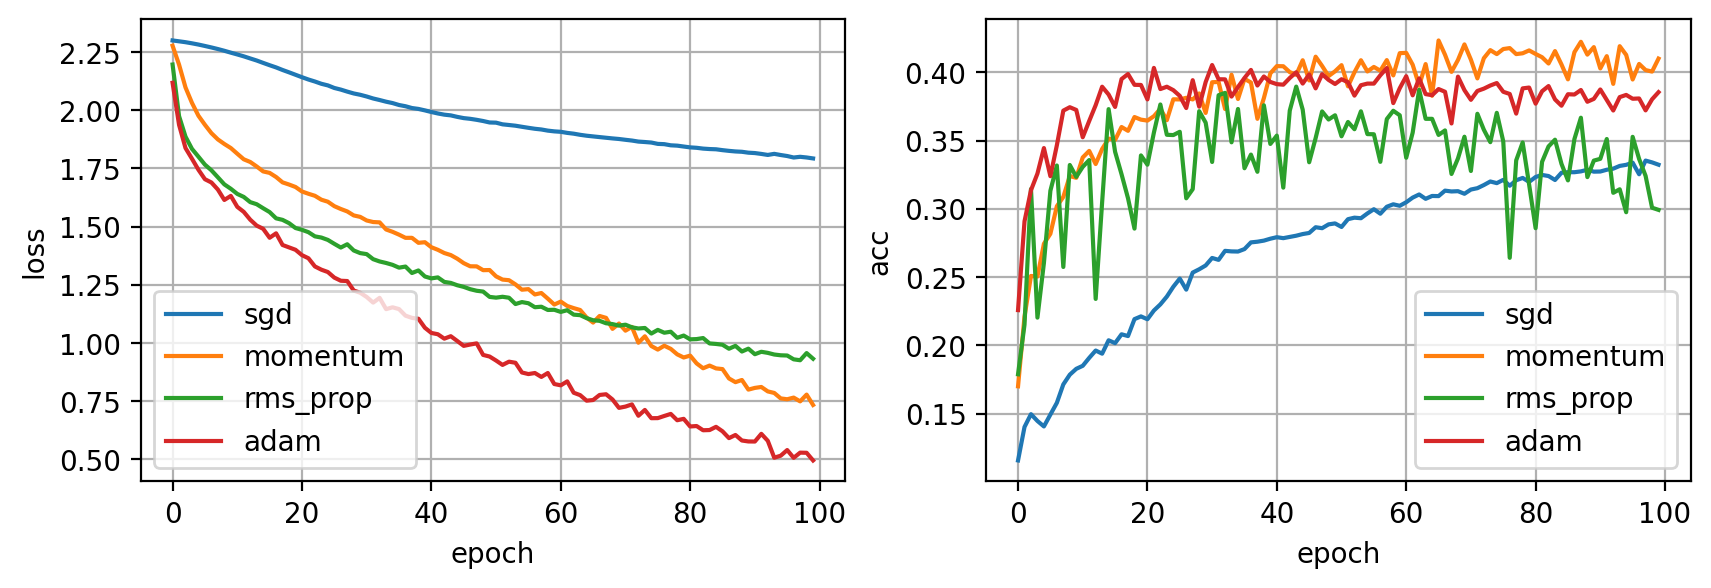

In [9]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="sgd")
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_rms['loss'], label="rms_prop")
ax.plot(hist_adam['loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="sgd")
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_rms['val_acc'], label="rms_prop")
ax.plot(hist_adam['val_acc'], label="adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

Como puedes ver, las variantes de *SGD* son capaces de converger mucho más rápido. Aún así, si le damos suficiente tiempo, *SGD* es capaz de llegar a los mismos resultados, e incluso superarlos. Existen muchos otros optimizadores, sin embargo los vistos aquí son los más comunes.

## *Learning Rate Scheduling*

Otra técninca muy utilizada para acelerar el proceso de entrenamiento de una `red neuronal` es el *learning rate scheduling* y consiste en ir variando el factor de aprendizaje durante el entrenamiento en vez de utilizar un valor fijo. Un valor alto del *learning rate* nos puede dar una ventaja en las fases iniciales del entrenamiento, en las que queremos acercarnos al punto óptimo de manera rápida. Aun así, no nos permitirá llegar al mejor valor posible ya que se quedará oscilando alrededor. En este punto, un learning rate pequeño nos permitiría acercarnos mucho más al valor óptimo, pero tardaría mucho en llegar en primer lugar.

![](https://camo.githubusercontent.com/051fc8fa68156d721512278e397dab5680dad77a/687474703a2f2f63733233316e2e6769746875622e696f2f6173736574732f6e6e332f6c6561726e696e6772617465732e6a706567)

La idea es combinar varios valores de *learning rate* para aprovechar las ventajas de cada uno en diferentes partes del entrenamiento. `Pytorch` nos ofrece algunos *schedulers* populares que podemos usar en el paquete `torch.optim.lr_scheduler`. Vamos a ver algunos ejemplos.

In [10]:
def fit(model, dataloader, optimizer, scheduler=None, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc, lr = [], [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        for param_group in optimizer.param_groups:
            lr.append(param_group['lr'])
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        if scheduler:
            scheduler.step()
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f} lr {lr[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc, 'lr': lr}

In [11]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# multiplica el lr por 0.1 cada 10 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 10, 0.1)

hist_step = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.21200 en epoch 1
Mejor modelo guardado con acc 0.27600 en epoch 2
Mejor modelo guardado con acc 0.28270 en epoch 3
Mejor modelo guardado con acc 0.33310 en epoch 4
Mejor modelo guardado con acc 0.33950 en epoch 5
Mejor modelo guardado con acc 0.34090 en epoch 7
Mejor modelo guardado con acc 0.34190 en epoch 8
Mejor modelo guardado con acc 0.35000 en epoch 10
Epoch 10/30 loss 1.69985 acc 0.38117 val_loss 1.83546 val_acc 0.35000 lr 0.01000
Mejor modelo guardado con acc 0.38430 en epoch 11
Mejor modelo guardado con acc 0.39280 en epoch 13
Mejor modelo guardado con acc 0.39410 en epoch 14
Mejor modelo guardado con acc 0.39730 en epoch 15
Mejor modelo guardado con acc 0.40070 en epoch 20
Epoch 20/30 loss 1.44332 acc 0.48229 val_loss 1.70572 val_acc 0.40070 lr 0.00100
Mejor modelo guardado con acc 0.40270 en epoch 21
Mejor modelo guardado con acc 0.40370 en epoch 23
Mejor modelo guardado con acc 0.40530 en epoch 24
Epoch 30/30 loss 1.40494 acc 0.49164 val_loss

In [12]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# aumenta el lr por 5 epochs, luego decrece
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0001, max_lr=0.01, step_size_up=5, step_size_down=25)

hist_cycle = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.13230 en epoch 1
Mejor modelo guardado con acc 0.21640 en epoch 2
Mejor modelo guardado con acc 0.26580 en epoch 3
Mejor modelo guardado con acc 0.31280 en epoch 5
Mejor modelo guardado con acc 0.31920 en epoch 6
Mejor modelo guardado con acc 0.34770 en epoch 7
Mejor modelo guardado con acc 0.35220 en epoch 8
Mejor modelo guardado con acc 0.37290 en epoch 10
Epoch 10/30 loss 1.69527 acc 0.39212 val_loss 1.75711 val_acc 0.37290 lr 0.00842
Mejor modelo guardado con acc 0.38350 en epoch 12
Mejor modelo guardado con acc 0.39060 en epoch 17
Mejor modelo guardado con acc 0.39460 en epoch 20
Epoch 20/30 loss 1.41243 acc 0.49204 val_loss 1.74810 val_acc 0.39460 lr 0.00446
Mejor modelo guardado con acc 0.40340 en epoch 21
Mejor modelo guardado con acc 0.40430 en epoch 24
Mejor modelo guardado con acc 0.40510 en epoch 25
Mejor modelo guardado con acc 0.41530 en epoch 26
Mejor modelo guardado con acc 0.41780 en epoch 27
Mejor modelo guardado con acc 0.42100 en epoc

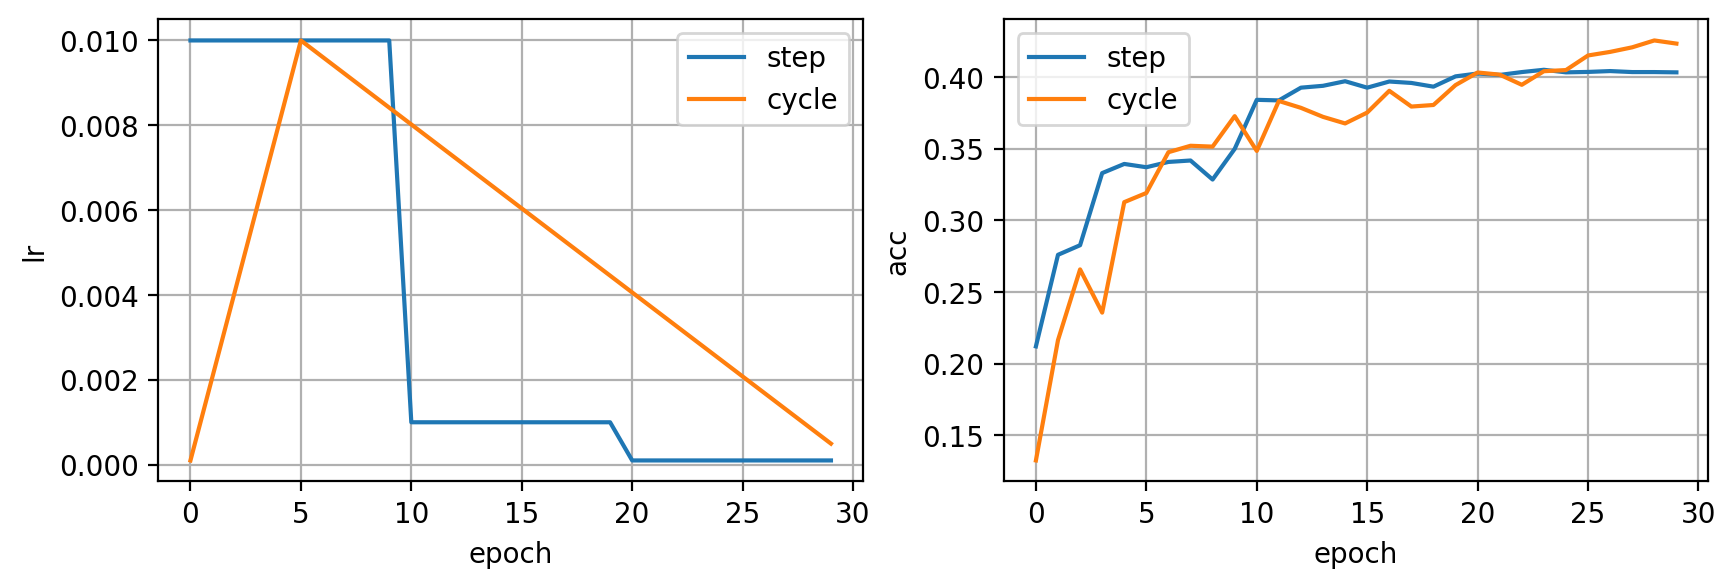

In [13]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_step['lr'], label="step")
ax.plot(hist_cycle['lr'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('lr')
ax = plt.subplot(122)
ax.plot(hist_step['val_acc'], label="step")
ax.plot(hist_cycle['val_acc'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

## Normalización

Otra técnica muy importante para acelerar el entrenamiento consiste en normalizar nuestros datos. Esto es algo de lo que ya hemos hablado en posts anteriores, y en este mismo post puedes ver como al principio de todo hemos dividido nuestras imágenes entre 255 de manera que los valores presentes en los tensores que nuestra `red neuronal` usa como entradas estén normalizados entre 0 y 1. Otra normalización popular, cuando trabajamos con imágenes, consiste en calcular el valor medio y desviación estándar de nuestro dataset, y normalizar las imágenes para que tengan media 0 y desviación estándar 1.

In [14]:
import numpy as np

mean = (train_images / 255).mean(axis=(0, 1, 2))
std = (train_images / 255).std(axis=(0, 1, 2))

mean, std

(array([0.49139968, 0.48215841, 0.44653091]),
 array([0.24703223, 0.24348513, 0.26158784]))

In [15]:
train_images_norm = ((train_images / 255) - mean) / std
train_images_norm.mean(axis=(0, 1, 2)), train_images_norm.std(axis=(0, 1, 2))

(array([-1.62320331e-11, -2.54226058e-11, -5.44383358e-11]),
 array([1., 1., 1.]))

In [16]:
X_test_norm = np.array([(np.array(img)/255. - mean) / std for img, label in testset])

X_train_norm, X_val_norm, X_subset_norm = train_images_norm[:40000], train_images_norm[40000:], train_images_norm[:5000]

X_train_norm.shape, X_val_norm.shape, X_test_norm.shape, X_subset_norm.shape

((40000, 32, 32, 3), (10000, 32, 32, 3), (10000, 32, 32, 3), (5000, 32, 32, 3))

In [17]:
dataset_norm = {
    'train': Dataset(X_subset_norm, y_subset),
    'val': Dataset(X_val_norm, y_val),
}

dataloader_norm = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset_norm['train']), len(dataset_norm['val'])

(5000, 10000)

In [18]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_norm = fit(model, dataloader_norm, optimizer)

Mejor modelo guardado con acc 0.15890 en epoch 1
Mejor modelo guardado con acc 0.20530 en epoch 2
Mejor modelo guardado con acc 0.22890 en epoch 3
Mejor modelo guardado con acc 0.25320 en epoch 4
Mejor modelo guardado con acc 0.27530 en epoch 5
Mejor modelo guardado con acc 0.29260 en epoch 6
Mejor modelo guardado con acc 0.30460 en epoch 7
Mejor modelo guardado con acc 0.32080 en epoch 8
Mejor modelo guardado con acc 0.32680 en epoch 10
Epoch 10/100 loss 1.83880 acc 0.34773 val_loss 1.88187 val_acc 0.32680 lr 0.00100
Mejor modelo guardado con acc 0.33190 en epoch 11
Mejor modelo guardado con acc 0.33310 en epoch 13
Mejor modelo guardado con acc 0.34770 en epoch 14
Mejor modelo guardado con acc 0.36130 en epoch 17
Mejor modelo guardado con acc 0.36750 en epoch 18
Epoch 20/100 loss 1.67646 acc 0.40685 val_loss 1.80979 val_acc 0.35560 lr 0.00100
Mejor modelo guardado con acc 0.36840 en epoch 21
Mejor modelo guardado con acc 0.37460 en epoch 22
Mejor modelo guardado con acc 0.37880 en epo

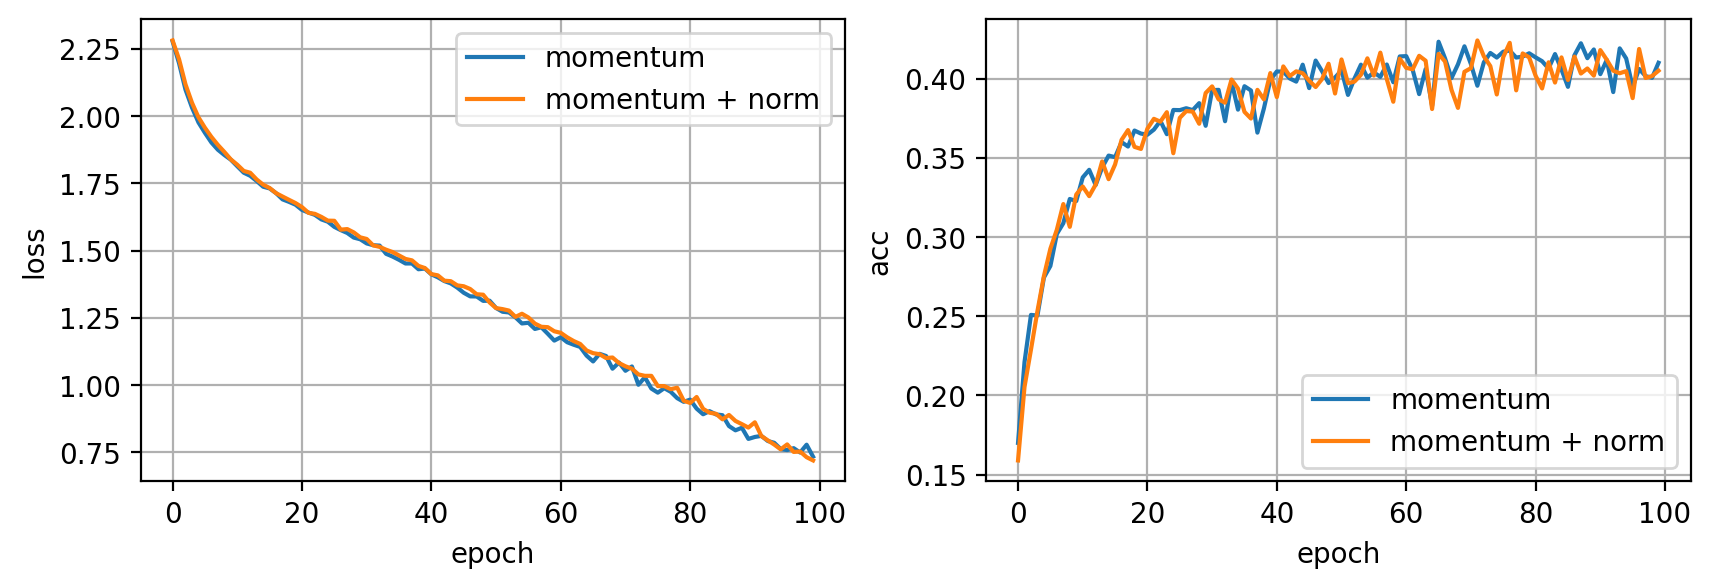

In [19]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_norm['loss'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_norm['val_acc'], label="momentum + norm")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

En este caso, el efecto de la normalización no es considerable (al trabajar con imágenes éste suele ser el caso).

### *Batch Normalization*

Otra forma de normalización muy importante que puede acelerar de manera dramática el entrenamiento es el *batch norm*. Podemos añadir esta capa en nuestras redes y su objetivo será el de normalizar sus entradas para que tengan media cero y desviación estándar 1. Además, aprenderá unos parámetros que le permitirán escalar y mover estos valores normalizados para mejorar sus representación, facilitando a la `red neuronal` la tarea de clasificación.

$$ \mu_B = \frac{1}{m_B} \sum_{i=1}^{m_B} x^{(i)} $$
$$ \sigma_B^2 = \frac{1}{m_B} \sum_{i=1}^{m_B} (x^{(i)} - \mu_B) $$
$$\hat{x}^{(i)} = \frac{x^{(i)} - \mu_b}{\sqrt{\sigma_B^2 + \epsilon}} $$
$$z^{(i)} = \gamma ⊗ \hat{x}^{(i)} + \beta $$

In [20]:
def build_model(D_in=32*32*3, H=100, D_out=10):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.BatchNorm1d(H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).cuda()

In [21]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
hist_bn = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.33270 en epoch 1
Mejor modelo guardado con acc 0.36410 en epoch 2
Mejor modelo guardado con acc 0.36620 en epoch 3
Mejor modelo guardado con acc 0.37020 en epoch 4
Mejor modelo guardado con acc 0.38030 en epoch 5
Mejor modelo guardado con acc 0.39090 en epoch 7
Epoch 10/100 loss 1.13618 acc 0.62699 val_loss 1.97545 val_acc 0.34670 lr 0.00100
Epoch 20/100 loss 0.64015 acc 0.80732 val_loss 2.43401 val_acc 0.32520 lr 0.00100
Epoch 30/100 loss 0.38642 acc 0.88336 val_loss 2.79672 val_acc 0.33720 lr 0.00100
Epoch 40/100 loss 0.27357 acc 0.91660 val_loss 2.80647 val_acc 0.34400 lr 0.00100
Epoch 50/100 loss 0.18022 acc 0.94845 val_loss 3.18883 val_acc 0.32510 lr 0.00100
Epoch 60/100 loss 0.12506 acc 0.96377 val_loss 3.10087 val_acc 0.36610 lr 0.00100
Epoch 70/100 loss 0.12460 acc 0.96377 val_loss 3.31835 val_acc 0.35120 lr 0.00100
Epoch 80/100 loss 0.08480 acc 0.97950 val_loss 3.85996 val_acc 0.32650 lr 0.00100
Epoch 90/100 loss 0.06251 acc 0.98447 val_loss 4.2

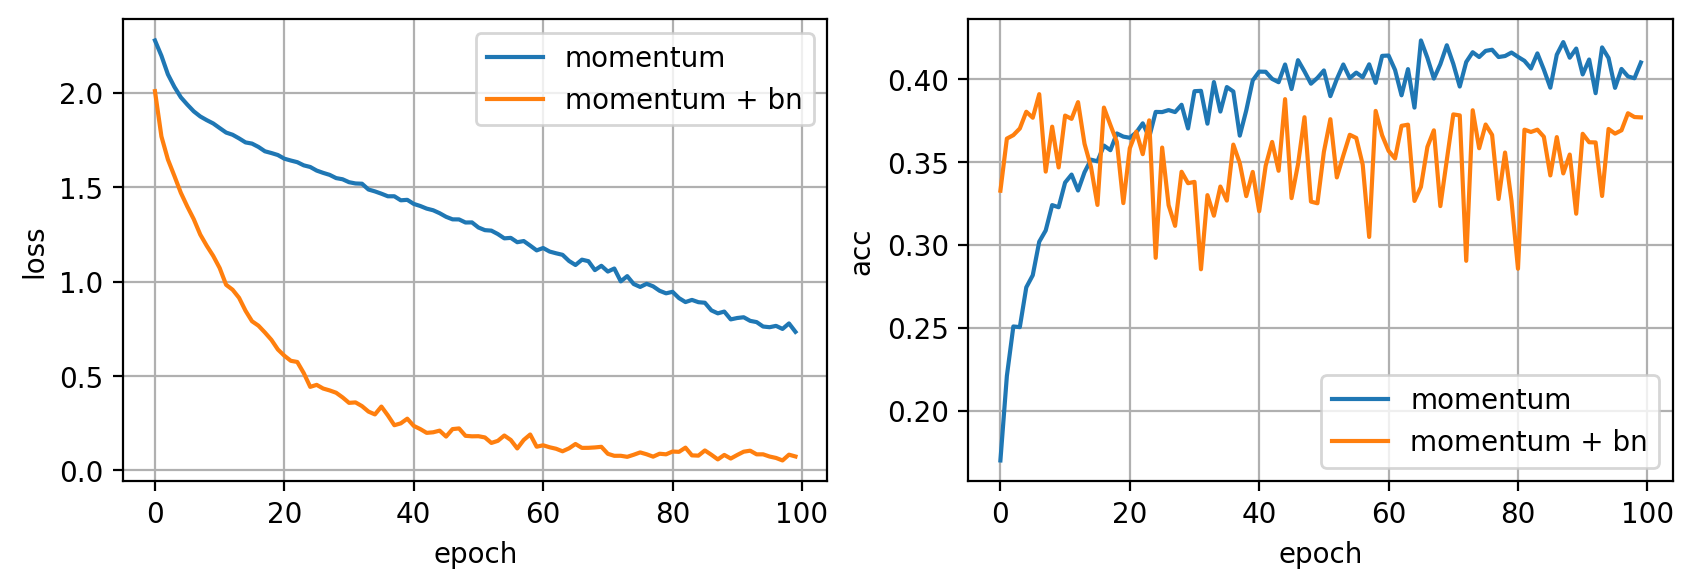

In [22]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_bn['loss'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_bn['val_acc'], label="momentum + bn")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

Como puedes observar, la introducción de la capa *Batch Norm* acelera muchísimo el entrenamiento, resultando en una reducción de la función de pérdida mucho más rápida (haciendo que nuestro modelo haga *overfitting* mucho más pronto). Combinando esta capa con alguna forma de [regularización](https://sensioai.com/blog/031_regularization), como por ejemplo *data augmentation* y *early stopping*, obtendremos buenos modelos capaces de generalizar de manera rápida.

## *Transfer Learning*

Posiblemente la técnica más interesante para acelerar el entrenamiento de un modelo es el *transfer learning*. No solo nos permite entrenar una red más rápido si no que además nos lo permite hacer con menos datos. Esta técnica consiste en utilizar una red ya entrenada en algún dataset como punto de partida para nuestro entrenamiento. Si nuestro dataset no es muy diferente al dataset utilizado originalmente para entrenar la red, es posible que podamos "transferir" el conocimiento que ya posee a nuestro caso. En la práctica, esta técnica funciona muy bien y nosotros la utilizaremos de manera extensiva en nuestras aplicaciones de ahora en adelante. En futuros posts entraremos en detalle en cómo aplicar transfer learning.

## Resumen

En este post hemos presentado varias técnicas para acelerar el proceso de entrenamiento de una `red neuronal`. Combinando estas técnicas con las presentadas en los posts anteriores seremos capaces de entrenar modelos con buenas prestaciones de forma rápida. Hemos visto como podemos mejorar nuestro optimizador *SGD* para acelerar el proceso de optimización, también que podemos ir variando el *learning rate* durante el entrenamiento. La normalización de los datos y el uso de la capa *Batch Norm* también nos aportarán una aceleración considerable. Y, por último, si podemos usar una red preentrenada en una tarea similar a la nuestra seremos capaces de obtener un buen modelo de manera rápida y con pocos datos gracias al *transfer learning*. En el próximo post encontrarás una receta en la que combinamos todas las técnicas vistas y que puedes seguir para empezar a entrenar tus redes de forma efectiva.